In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
from collections import deque

np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
class MazeEnvironment:
    def __init__(self):
        # 0 = Free path
        # 1 = Obstacle
        self.maze = np.array([
            [0, 0, 0, 0, 0, 0],
            [0, 1, 1, 0, 1, 0],
            [0, 0, 0, 0, 1, 0],
            [1, 1, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 1],
            [0, 1, 0, 1, 0, 0]
        ])

        self.rows, self.cols = self.maze.shape

        self.start_position = (0, 0)
        self.goal_position = (5, 5)

        self.current_position = self.start_position

        # Actions:
        # 0 = Up
        # 1 = Down
        # 2 = Left
        # 3 = Right
        self.actions = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

    def reset(self):
        self.current_position = self.start_position
        return self.position_to_state(self.current_position)

    def position_to_state(self, position):
        row, col = position
        return row * self.cols + col

    def state_to_position(self, state):
        row = state // self.cols
        col = state % self.cols
        return row, col

    def step(self, action):
        row, col = self.current_position
        row_change, col_change = self.actions[action]

        new_row = row + row_change
        new_col = col + col_change

        # Penalty for hitting maze boundary
        if (
            new_row < 0
            or new_row >= self.rows
            or new_col < 0
            or new_col >= self.cols
        ):
            reward = -10
            done = False
            return self.position_to_state(self.current_position), reward, done

        # Penalty for hitting an obstacle
        if self.maze[new_row, new_col] == 1:
            reward = -10
            done = False
            return self.position_to_state(self.current_position), reward, done

        self.current_position = (new_row, new_col)

        # Reward for reaching the goal
        if self.current_position == self.goal_position:
            reward = 100
            done = True
        else:
            # Small penalty encourages the shortest path
            reward = -1
            done = False

        next_state = self.position_to_state(self.current_position)

        return next_state, reward, done

In [3]:
environment = MazeEnvironment()

initial_state = environment.reset()

print("Maze shape:", environment.maze.shape)
print("Start position:", environment.start_position)
print("Goal position:", environment.goal_position)
print("Initial state number:", initial_state)

Maze shape: (6, 6)
Start position: (0, 0)
Goal position: (5, 5)
Initial state number: 0


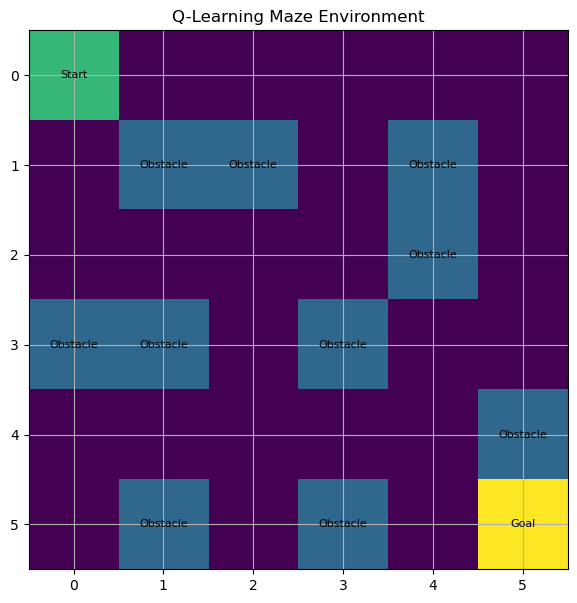

In [4]:
def plot_maze(environment, path=None, title="Q-Learning Maze Environment"):
    maze_display = environment.maze.copy().astype(float)

    start_row, start_col = environment.start_position
    goal_row, goal_col = environment.goal_position

    maze_display[start_row, start_col] = 2
    maze_display[goal_row, goal_col] = 3

    if path:
        for row, col in path:
            if (row, col) not in [
                environment.start_position,
                environment.goal_position
            ]:
                maze_display[row, col] = 4

    plt.figure(figsize=(7, 7))
    plt.imshow(maze_display)

    for row in range(environment.rows):
        for col in range(environment.cols):
            if environment.maze[row, col] == 1:
                label = "Obstacle"
            elif (row, col) == environment.start_position:
                label = "Start"
            elif (row, col) == environment.goal_position:
                label = "Goal"
            elif path and (row, col) in path:
                label = "Path"
            else:
                label = ""

            plt.text(
                col,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    plt.xticks(range(environment.cols))
    plt.yticks(range(environment.rows))
    plt.grid(True)
    plt.title(title)
    plt.show()


plot_maze(environment)

In [5]:
environment = MazeEnvironment()

number_of_states = environment.rows * environment.cols
number_of_actions = len(environment.actions)

q_table = np.zeros((number_of_states, number_of_actions))

# Training parameters
episodes = 2000
max_steps_per_episode = 200

learning_rate = 0.1
discount_factor = 0.95

epsilon = 1.0
minimum_epsilon = 0.01
epsilon_decay = 0.995

print("Number of states:", number_of_states)
print("Number of actions:", number_of_actions)
print("Q-table shape:", q_table.shape)

Number of states: 36
Number of actions: 4
Q-table shape: (36, 4)


In [6]:
episode_rewards = []
episode_steps = []
epsilon_history = []
success_history = []

for episode in range(episodes):

    current_state = environment.reset()

    total_reward = 0
    reached_goal = False

    for step in range(max_steps_per_episode):

        # Exploration: choose a random action
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, number_of_actions - 1)

        # Exploitation: choose the action with the highest Q-value
        else:
            action = np.argmax(q_table[current_state])

        next_state, reward, done = environment.step(action)

        # Current Q-value
        old_q_value = q_table[current_state, action]

        # Best future Q-value
        next_max_q_value = np.max(q_table[next_state])

        # Q-learning update equation
        new_q_value = old_q_value + learning_rate * (
            reward
            + discount_factor * next_max_q_value
            - old_q_value
        )

        q_table[current_state, action] = new_q_value

        current_state = next_state
        total_reward += reward

        if done:
            reached_goal = True
            break

    # Reduce exploration after every episode
    epsilon = max(minimum_epsilon, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    episode_steps.append(step + 1)
    epsilon_history.append(epsilon)
    success_history.append(1 if reached_goal else 0)

print("Training completed successfully!")
print("Final epsilon:", round(epsilon, 4))

Training completed successfully!
Final epsilon: 0.01


In [7]:
action_names = ["Up", "Down", "Left", "Right"]

q_table_dataframe = pd.DataFrame(
    q_table,
    columns=action_names
)

q_table_dataframe.index.name = "State"

q_table_dataframe.head(10)

,Up,Down,Left,Right
State,,,,
0,42.211417,55.629929,42.536438,46.279578
1,9.310350,14.671093,51.447747,-2.008286
2,-12.976649,-11.965311,1.167116,4.512312
3,-8.603802,23.139735,-4.016370,-2.202107
4,-11.658673,-12.221223,-1.850421,1.186046
5,-10.472879,5.448118,-2.181799,-8.658289
6,51.016339,59.610452,46.517691,46.386956
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000


In [8]:
success_rate = np.mean(success_history) * 100
average_reward = np.mean(episode_rewards)
average_steps = np.mean(episode_steps)

last_100_success_rate = np.mean(success_history[-100:]) * 100
last_100_average_reward = np.mean(episode_rewards[-100:])
last_100_average_steps = np.mean(episode_steps[-100:])

print("Overall Training Performance")
print("-" * 35)
print(f"Success rate: {success_rate:.2f}%")
print(f"Average reward: {average_reward:.2f}")
print(f"Average steps: {average_steps:.2f}")

print("\nLast 100 Episodes")
print("-" * 35)
print(f"Success rate: {last_100_success_rate:.2f}%")
print(f"Average reward: {last_100_average_reward:.2f}")
print(f"Average steps: {last_100_average_steps:.2f}")

Overall Training Performance
-----------------------------------
Success rate: 99.45%
Average reward: 69.52
Average steps: 14.30

Last 100 Episodes
-----------------------------------
Success rate: 100.00%
Average reward: 90.66
Average steps: 10.07


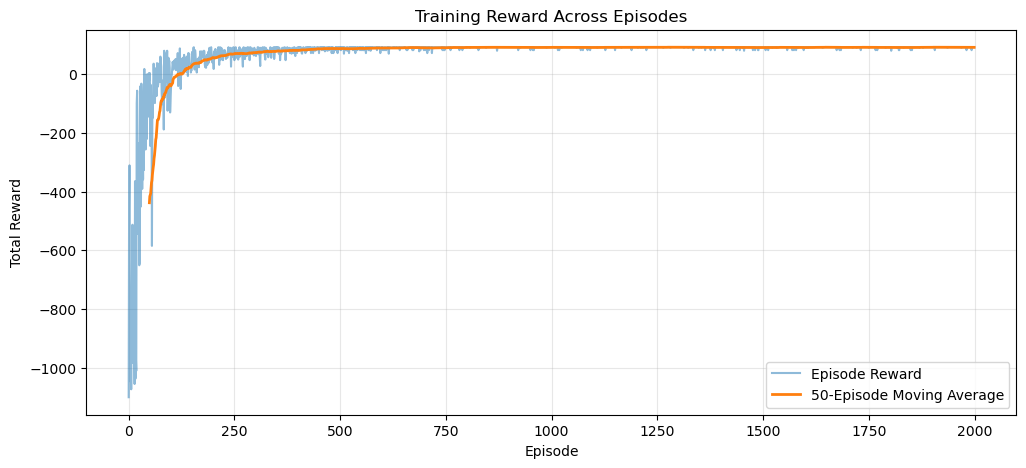

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(episode_rewards, alpha=0.5, label="Episode Reward")

reward_series = pd.Series(episode_rewards)
moving_average_reward = reward_series.rolling(window=50).mean()

plt.plot(
    moving_average_reward,
    linewidth=2,
    label="50-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward Across Episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

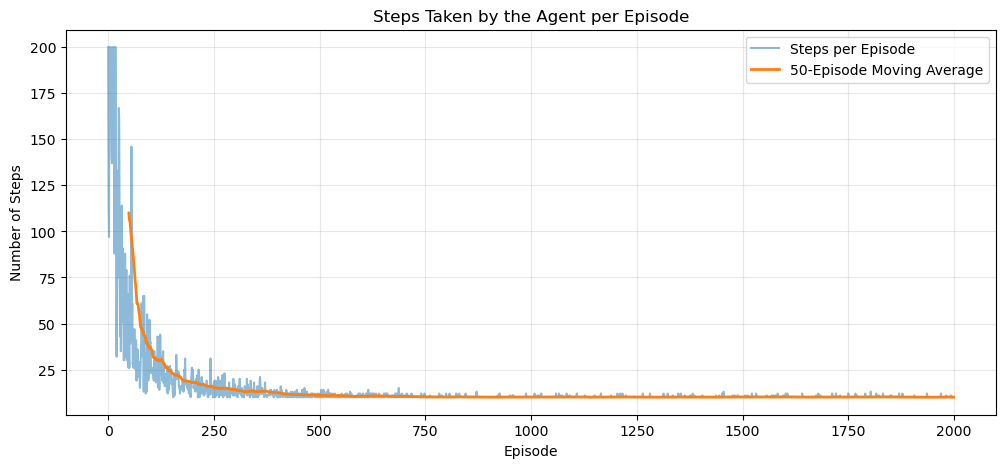

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(episode_steps, alpha=0.5, label="Steps per Episode")

steps_series = pd.Series(episode_steps)
moving_average_steps = steps_series.rolling(window=50).mean()

plt.plot(
    moving_average_steps,
    linewidth=2,
    label="50-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Number of Steps")
plt.title("Steps Taken by the Agent per Episode")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

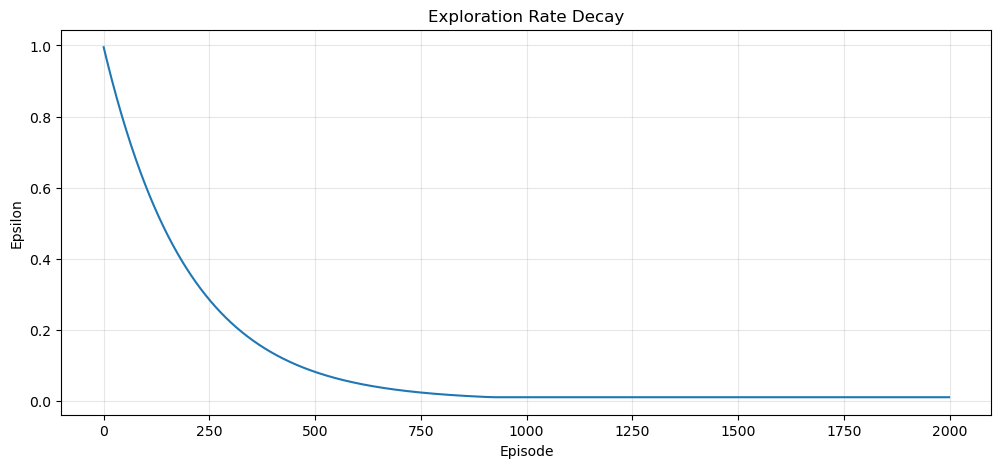

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(epsilon_history)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Rate Decay")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
def extract_optimal_path(environment, q_table, max_steps=100):
    state = environment.reset()
    path = [environment.start_position]
    visited_states = set()

    for _ in range(max_steps):
        if state in visited_states:
            print("Loop detected while extracting the path.")
            break

        visited_states.add(state)

        action = np.argmax(q_table[state])
        next_state, reward, done = environment.step(action)

        next_position = environment.state_to_position(next_state)
        path.append(next_position)

        state = next_state

        if done:
            return path, True

    return path, False


optimal_path, reached_goal = extract_optimal_path(
    environment,
    q_table
)

print("Goal reached:", reached_goal)
print("Optimal path:", optimal_path)
print("Number of moves:", len(optimal_path) - 1)

Goal reached: True
Optimal path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (5, 4), (5, 5)]
Number of moves: 10


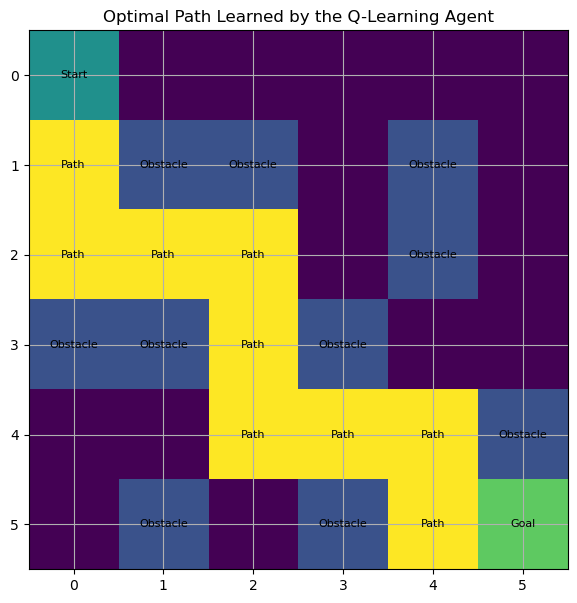

In [13]:
plot_maze(
    environment,
    path=optimal_path,
    title="Optimal Path Learned by the Q-Learning Agent"
)

In [14]:
def display_policy(environment, q_table):
    symbols = {
        0: "↑",
        1: "↓",
        2: "←",
        3: "→"
    }

    policy_grid = np.full(
        (environment.rows, environment.cols),
        "",
        dtype=object
    )

    for row in range(environment.rows):
        for col in range(environment.cols):
            position = (row, col)

            if environment.maze[row, col] == 1:
                policy_grid[row, col] = "■"

            elif position == environment.start_position:
                state = environment.position_to_state(position)
                best_action = np.argmax(q_table[state])
                policy_grid[row, col] = "S" + symbols[best_action]

            elif position == environment.goal_position:
                policy_grid[row, col] = "G"

            else:
                state = environment.position_to_state(position)
                best_action = np.argmax(q_table[state])
                policy_grid[row, col] = symbols[best_action]

    return policy_grid


policy_grid = display_policy(environment, q_table)

policy_dataframe = pd.DataFrame(policy_grid)
policy_dataframe

,0,1,2,3,4,5
0,S↓,←,→,↓,→,↓
1,↓,■,■,↓,■,↓
2,→,→,↓,←,■,↓
3,■,■,↓,■,↓,←
4,→,→,→,→,↓,■
5,↑,■,↑,■,→,G


In [15]:
import seaborn as sns

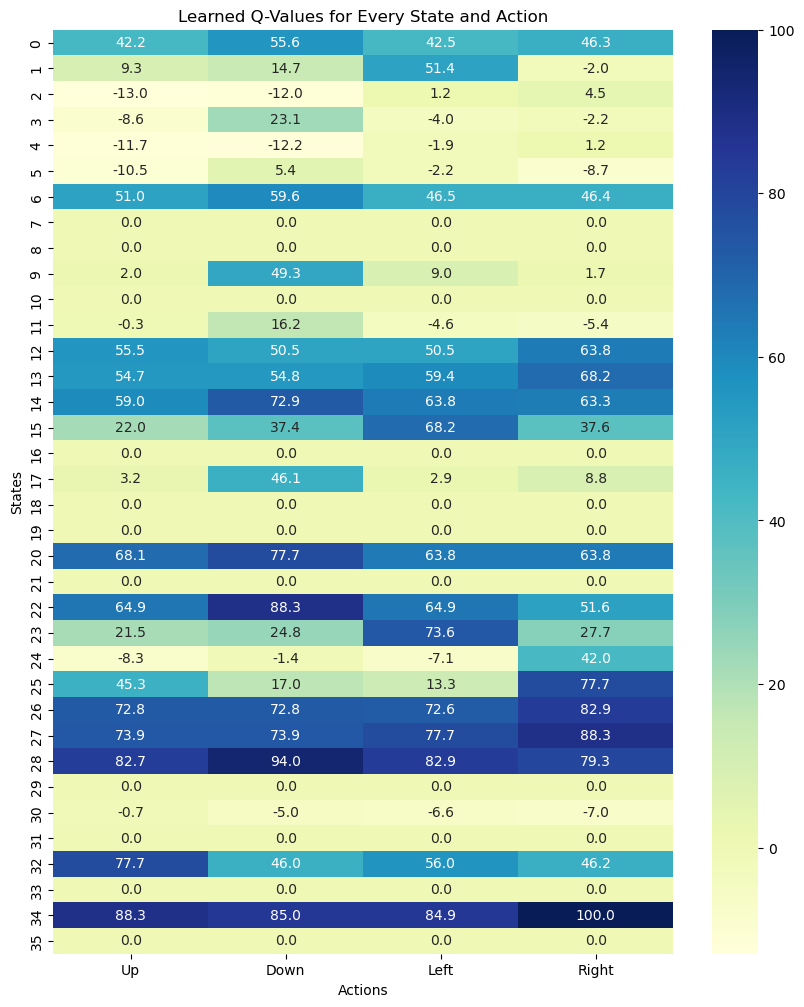

In [16]:
plt.figure(figsize=(10, 12))

sns.heatmap(
    q_table_dataframe,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Learned Q-Values for Every State and Action")
plt.xlabel("Actions")
plt.ylabel("States")
plt.show()

In [17]:
evaluation_results = {
    "Total Episodes": episodes,
    "Overall Success Rate (%)": round(success_rate, 2),
    "Last 100 Success Rate (%)": round(last_100_success_rate, 2),
    "Overall Average Reward": round(average_reward, 2),
    "Last 100 Average Reward": round(last_100_average_reward, 2),
    "Overall Average Steps": round(average_steps, 2),
    "Last 100 Average Steps": round(last_100_average_steps, 2),
    "Optimal Path Moves": len(optimal_path) - 1,
    "Final Epsilon": round(epsilon, 4)
}

evaluation_dataframe = pd.DataFrame(
    evaluation_results.items(),
    columns=["Metric", "Value"]
)

evaluation_dataframe

,Metric,Value
0,Total Episodes,2000.00
1,Overall Success Rate (%),99.45
2,Last 100 Success Rate (%),100.00
3,Overall Average Reward,69.52
4,Last 100 Average Reward,90.66
5,Overall Average Steps,14.30
6,Last 100 Average Steps,10.07
7,Optimal Path Moves,10.00
8,Final Epsilon,0.01


In [18]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

np.save("models/q_table.npy", q_table)

training_history = pd.DataFrame({
    "Episode": range(1, episodes + 1),
    "Reward": episode_rewards,
    "Steps": episode_steps,
    "Epsilon": epsilon_history,
    "Success": success_history
})

training_history.to_csv(
    "results/training_history.csv",
    index=False
)

evaluation_dataframe.to_csv(
    "results/evaluation_metrics.csv",
    index=False
)

optimal_path_dataframe = pd.DataFrame(
    optimal_path,
    columns=["Row", "Column"]
)

optimal_path_dataframe.to_csv(
    "results/optimal_path.csv",
    index=False
)

print("Q-table saved to models/q_table.npy")
print("Training history saved successfully")
print("Evaluation metrics saved successfully")
print("Optimal path saved successfully")

Q-table saved to models/q_table.npy
Training history saved successfully
Evaluation metrics saved successfully
Optimal path saved successfully
